In [2]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve,accuracy_score,f1_score,precision_score,recall_score

In [3]:
class IdentityMetadata():
    def __init__(self, base, name, file):
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    
# def load_metadata(path):
#     metadata = []
#     for i in os.listdir(path):
#         for f in os.listdir(os.path.join(path, i)):
#             # Check file extension. Allow only jpg/jpeg' files.
#             ext = os.path.splitext(f)[1]
#             if ext == '.jpg' or ext == '.jpeg':
#                 metadata.append(IdentityMetadata(path, i, f))
#     return np.array(metadata)

In [4]:
import cv2
def load_image(path):
    img = cv2.imread(path, 1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

2023-04-06 23:37:38.614822: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-06 23:37:38.869324: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-06 23:37:38.895567: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/sarank21/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-04-06 23:3

In [6]:
model = vgg_face()
model.load_weights('vgg_face_weights.h5')

2023-04-06 23:37:41.027360: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/sarank21/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-04-06 23:37:41.027598: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-04-06 23:37:41.027641: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (Nick): /proc/driver/nvidia/version does not exist
2023-04-06 23:37:41.028534: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the a

In [7]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

In [8]:
def load_metadata(path):
    metadata = []
    for f in os.listdir(os.path.join('Attack_images', path)):
        # Check file extension. Allow only jpg/jpeg' files.
        ext = os.path.splitext(f)[1]
        if ext == '.jpg' or ext == '.jpeg':
            metadata.append(IdentityMetadata('Attack_images', path, f))
    return np.array(metadata)

metadata_attack = load_metadata('pins_Bobby Morley')
metadata_6 = np.load('numpy docs/metadata_6.npy', allow_pickle=True)

In [9]:
attack_embeddings = np.zeros((metadata_attack.shape[0], 2622))
for i, m in enumerate(metadata_attack):
    img_path = metadata_attack[i].image_path()
    img = load_image(img_path)
    img = (img / 255.).astype(np.float32)
    img = cv2.resize(img, dsize = (224,224))
    embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
    attack_embeddings[i]=embedding_vector

print("Embeddings "+str(metadata_attack.shape[0])+" are changed")
k = metadata_attack.shape[0]

1/1 [==============================] - 0s 430ms/step
Embeddings 5 are changed


In [10]:
img_path = 'Attack_images/Imgs/Bobby Morley38_349.jpg'
img = load_image(img_path)
img = (img / 255.).astype(np.float32)
img = cv2.resize(img, dsize = (224,224))
print(img.shape)
original_img_embedding = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]

(224, 224, 3)
1/1 [==============================] - 0s 481ms/step


In [11]:
embeddings = np.load('numpy docs/embeddings_6class.npy')
targets = np.array([m.name for m in metadata_6])

In [37]:
k=1

In [38]:
embeddings[0] = original_img_embedding
embeddings[1] = attack_embeddings[k]

In [39]:
targets[0] = 'pins_Bobby Morley'
targets[1] = 'pins_Bobby Morley'

In [40]:
# Standarize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_emb = scaler.fit_transform(embeddings)
# X_all_std = scaler.transform(X_all)

In [41]:
X_train_std = np.load('numpy docs/X_train_std.npy')

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128)
X_train_pca = pca.fit_transform(X_train_std)
embed_final = pca.transform(scaled_emb)

In [43]:
clf1 = pickle.load(open('model1_6.sav', 'rb'))
y_predict = clf1.predict(embed_final)

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
targets_encoded = le.fit_transform(targets)


In [45]:
print(accuracy_score(targets_encoded, y_predict))


0.9978655282817502


In [46]:
y_predict_encoded = le.inverse_transform(y_predict)

Text(0.5, 1.0, 'Identified as pins_Brenton Thwaites')

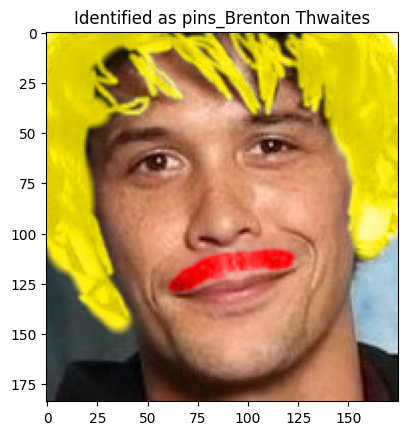

In [47]:
attack_idx = k


example_image = load_image(metadata_attack[attack_idx].image_path())
example_prediction = y_predict[1]
example_identity =  y_predict_encoded[1]

plt.imshow(example_image)
plt.title(f'Identified as {example_identity}')

In [48]:
for i in range(0, 2):
    results = clf1.predict_proba(embed_final)[i]
    print(i, end=" ")
    # gets a dictionary of {'class_name': probability}
    prob_per_class_dictionary = dict(zip(clf1.classes_, results))
    print(prob_per_class_dictionary)

0 {0: 0.0011144090346828506, 1: 0.9975015620655627, 2: 0.000278769773570119, 3: 0.0007329493827981175, 4: 0.00020391574491524758, 5: 0.00016839399847151543}
1 {0: 0.008997581999877867, 1: 0.2953250098456131, 2: 0.6409868771047448, 3: 0.03257866801140017, 4: 0.013377519571365555, 5: 0.008734343466998341}


Original - 0.9973556765666659
1 - 0.8462471057734143
3 - 0.2920269141888476 (Brenton Thwaites(2) - 0.6441489432615748)
6 - 0.903547011879328
8 - 0.6474163571654831
10 - 0.8068063286417343